In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("best_data.csv")

# PCA

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [46]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [47]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [48]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [49]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [50]:
pca = PCA(n_components=0.85)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

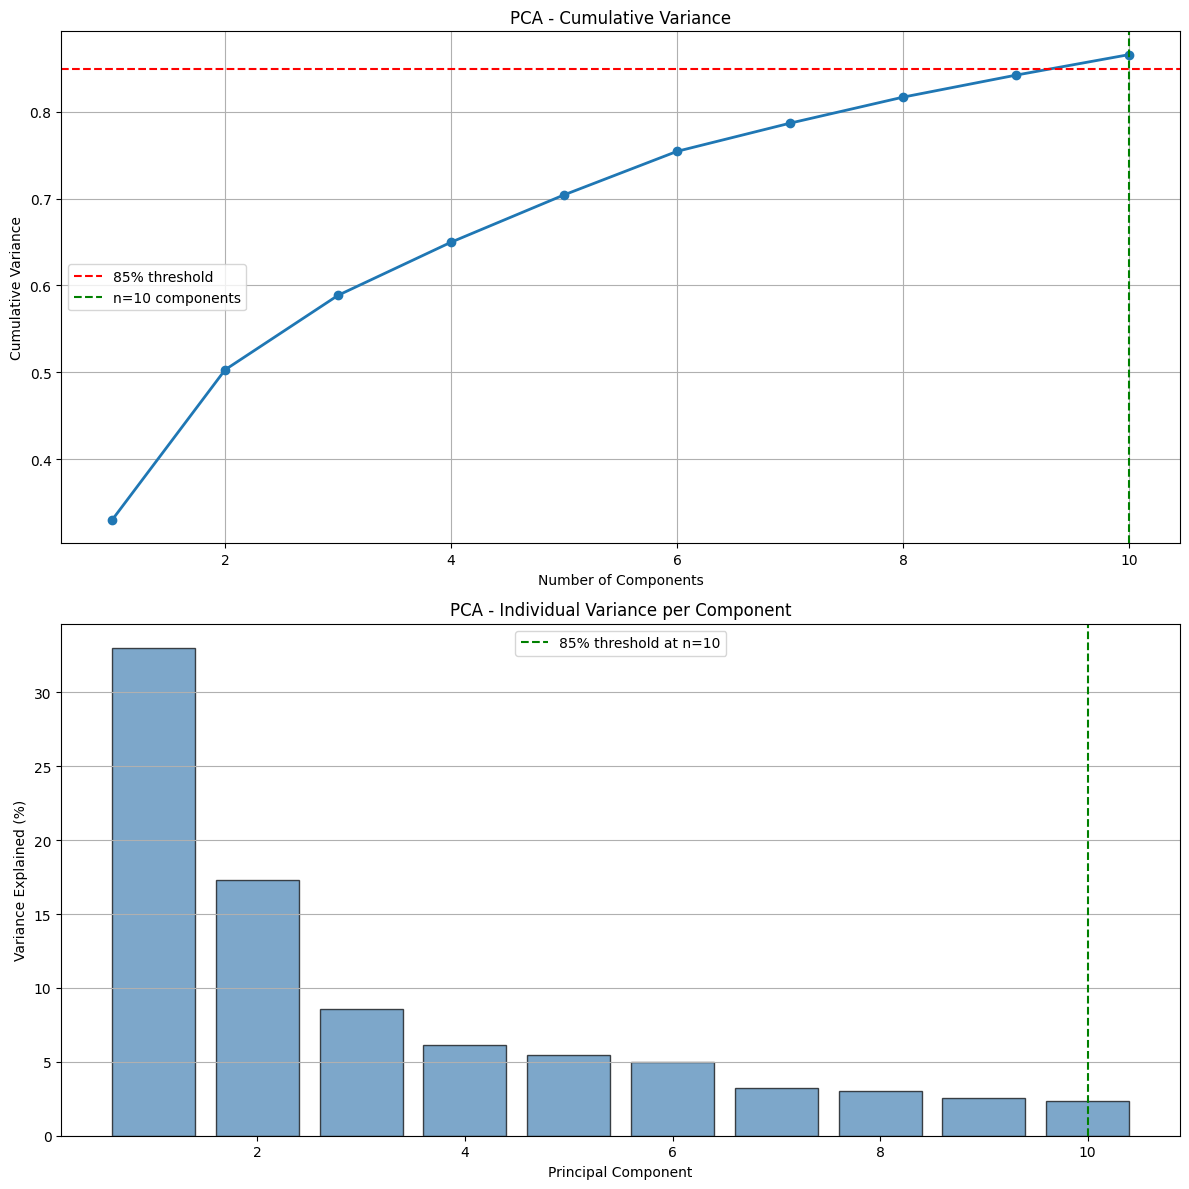

✅ Components needed for 85% variance: 10
✅ Variance explained by 10 components: 0.8661


In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_85 = np.argmax(cumvar >= 0.85) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
ax1.axvline(x=n_components_85, color='g', linestyle='--', 
            label=f'n={n_components_85} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_85, color='g', linestyle='--',
            label=f'85% threshold at n={n_components_85}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 85% variance: {n_components_85}")
print(f"✅ Variance explained by {n_components_85} components: {cumvar[n_components_85-1]:.4f}")

In [52]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_month], axis=1)

# lazyPredict

In [32]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [33]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared     R-Squared         RMSE  \
Model                                                                          
HistGradientBoostingRegressor            0.376818      0.388037     7.577383   
ExtraTreesRegressor                      0.370656      0.381986     7.614756   
RandomForestRegressor                    0.355009      0.366621     7.708831   
BaggingRegressor                         0.332435      0.344454     7.842572   
GradientBoostingRegressor                0.308779      0.321223     7.980320   
MLPRegressor                             0.308325      0.320778     7.982939   
XGBRegressor                             0.276789      0.289809     8.162900   
KNeighborsRegressor                      0.264937      0.278170     8.229515   
PoissonRegressor                         0.184771      0.199447     8.666659   
Lars                                     0.095896      0.112173     9.126854   
TransformedTargetRegressor              

In [54]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor

# OpTuna

In [35]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_train_no_month = X_train_raw.copy()   # numeric only (month already dropped earlier)
X_train_month    = X_train_raw_month.reset_index(drop=True)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [36]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.85)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-06 10:08:08,322] A new study created in memory with name: no-name-6c94037e-56d8-4f37-829f-d2895ac0bfb7
[I 2026-05-06 10:08:09,163] Trial 0 finished with value: 0.13718705190603533 and parameters: {'n_estimators': 269, 'max_depth': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.13718705190603533.
[I 2026-05-06 10:08:09,609] Trial 1 finished with value: 0.16015621005754796 and parameters: {'n_estimators': 89, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.16015621005754796.
[I 2026-05-06 10:08:10,014] Trial 2 finished with value: 0.20477884913650438 and parameters: {'n_estimators': 75, 'max_depth': 18, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with value: 0.20477884913650438.
[I 2026-05-06 10:08:10,435] Trial 3 finished with value: 0.16840972734917273 and parameters: {'n_estimators': 71, 'max_depth': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with v

========== ET BEST ==========
{'n_estimators': 139, 'max_depth': 37, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.3068


In [37]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.85)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-06 10:08:42,338] A new study created in memory with name: no-name-5e1bf14e-b4ad-4e21-97c6-2b2912551bd7
[I 2026-05-06 10:08:43,201] Trial 0 finished with value: 0.23441988713529416 and parameters: {'n_estimators': 118, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.23441988713529416.
[I 2026-05-06 10:08:44,595] Trial 1 finished with value: 0.2814035956186522 and parameters: {'n_estimators': 189, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.2814035956186522.
[I 2026-05-06 10:08:45,791] Trial 2 finished with value: 0.23706596354993895 and parameters: {'n_estimators': 188, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.2814035956186522.
[I 2026-05-06 10:08:47,251] Trial 3 finished with value: 0.23253575835942436 and parameters: {'n_estimators': 251, 'max_depth': 14

========== RF BEST ==========
{'n_estimators': 97, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.2914


In [38]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int  ("max_iter",          50, 400),
        max_depth         = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate     = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf  = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.85)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

[I 2026-05-06 10:09:39,558] A new study created in memory with name: no-name-0cd4cf3f-e1ca-48a9-aa67-caa8be29fe10
[I 2026-05-06 10:09:40,398] Trial 0 finished with value: 0.24445366625903514 and parameters: {'max_iter': 159, 'max_depth': 5, 'learning_rate': 0.04983128462645878, 'min_samples_leaf': 4, 'l2_regularization': 0.8957516165911565}. Best is trial 0 with value: 0.24445366625903514.
[I 2026-05-06 10:09:42,346] Trial 1 finished with value: 0.2103510073790783 and parameters: {'max_iter': 278, 'max_depth': 12, 'learning_rate': 0.07467012667302897, 'min_samples_leaf': 2, 'l2_regularization': 0.5746299197112588}. Best is trial 0 with value: 0.24445366625903514.
[I 2026-05-06 10:09:43,345] Trial 2 finished with value: 0.20877592597900121 and parameters: {'max_iter': 375, 'max_depth': 4, 'learning_rate': 0.029739412449873104, 'min_samples_leaf': 47, 'l2_regularization': 0.4227729674249524}. Best is trial 0 with value: 0.24445366625903514.
[I 2026-05-06 10:09:45,553] Trial 3 finished wi

========== HGB BEST ==========
{'max_iter': 160, 'max_depth': 12, 'learning_rate': 0.05860766200675815, 'min_samples_leaf': 8, 'l2_regularization': 0.7611631728515011}
Best R²: 0.2582


# Start

In [55]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=160,
    max_depth=12,
    learning_rate=0.0586,
    min_samples_leaf=8,
    l2_regularization=0.761,
    random_state=42
)
# {'max_iter': 160, 'max_depth': 12, 'learning_rate': 0.05860766200675815, 'min_samples_leaf': 8, 'l2_regularization': 0.7611631728515011}


et_model = ExtraTreesRegressor(
    n_estimators=139,
    max_depth=37,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 139, 'max_depth': 37, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


rf_model = RandomForestRegressor(
    n_estimators=97, 
    max_depth=27, 
    min_samples_split =  2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1, 
    random_state=42
)
# {'n_estimators': 97, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}



In [56]:
from sklearn.metrics import mean_absolute_error

In [57]:
voting = VotingRegressor([
    ('hgb', hgb_model),
    ('et',  et_model),
    ('rf',  rf_model)
])

# Train all
hgb_model.fit(X_train_pca, y_train)
et_model.fit(X_train_pca, y_train)
rf_model.fit(X_train_pca, y_train)
voting.fit(X_train_pca, y_train)

models = {
    'HistGradientBoost': hgb_model,
    'ExtraTrees':        et_model,
    'RandomForest':      rf_model,
    'Voting (Ensemble)': voting
}

print("=" * 65)
print("BASELINE RESULTS (single seed = 42)")
print("=" * 65)
print(f"{'Model':<22}{'R²':>10}{'RMSE':>12}{'MAE':>10}{'Acc%':>10}")
print("-" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{name:<22}{r2:>10.4f}{rmse:>12.4f}{mae:>10.4f}{100-mae:>10.2f}")
print("-" * 65)
print(f"{'Paper baseline:':<22}{0.25:>10.4f}{7.91:>12.4f}{'—':>10}{96:>10.2f}")
print("=" * 65)

BASELINE RESULTS (single seed = 42)
Model                         R²        RMSE       MAE      Acc%
-----------------------------------------------------------------
HistGradientBoost         0.3864      7.5876    3.2992     96.70
ExtraTrees                0.4214      7.3681    3.2199     96.78
RandomForest              0.4118      7.4287    3.4298     96.57
Voting (Ensemble)         0.4425      7.2326    3.2606     96.74
-----------------------------------------------------------------
Paper baseline:           0.2500      7.9100         —     96.00


# K-Fold

In [58]:
from sklearn.model_selection import KFold

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Separate month columns before the loop
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_month    = X[month_cols].copy()
X_no_month = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'HistGraHoost':         hgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_no_month):
        # Split numeric and month separately
        X_fold_train, X_fold_test = X_no_month.iloc[train_idx], X_no_month.iloc[test_idx]
        month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
        month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
        y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=0.85)
        X_train_pca = pca.fit_transform(X_train_ss)
        X_test_pca  = pca.transform(X_test_ss)

        # Reattach month columns after PCA
        n_pcs   = X_train_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([pd.DataFrame(X_train_pca, columns=pc_cols), month_fold_train], axis=1)
        X_test_final  = pd.concat([pd.DataFrame(X_test_pca,  columns=pc_cols), month_fold_test ], axis=1)

        # Train & evaluate (clone to avoid refitting same instance)
        from sklearn.base import clone
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.3869        7.4977        3.1599
RandomForest                  0.3410        7.7842        3.3912
HistGraHoost                  0.3627        7.6313        3.3259
Voting (Ensemble)             0.3944        7.4542        3.2262
